In [ ]:
pip install optuna

In [ ]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMRegressor
import shap
import optuna
import io
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBRegressor
from google.colab import files
from sklearn.base import clone
from scipy.stats import spearmanr
from matplotlib.colors import ListedColormap
from sklearn.utils import resample
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import RepeatedKFold
import scipy.stats as stats
from itertools import combinations

In [ ]:
# file upload
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

Saving updated_dataset_logistic_risk_score.csv to updated_dataset_logistic_risk_score (2).csv


In [ ]:
# preprocessing
target_col = 'probabilistic_risk_score'
flag_cols = [col for col in df.columns if 'was_imputed' in col.lower()]
exclude_from_model = ['num_thresholds_exceeded'] + flag_cols

# Drop non-predictive metadata
non_predictive = ['Bank_Name', 'State', 'Region', 'QuarterLabel']
df.drop(columns=[col for col in non_predictive if col in df.columns], inplace=True)

# Time-based split
df_sorted = df.sort_values(by='Quarter').reset_index(drop=True)
split_point = int(df_sorted['Quarter'].max() * 0.8)

train_df = df_sorted[df_sorted['Quarter'] <= split_point].copy()
test_df = df_sorted[df_sorted['Quarter'] > split_point].copy()

# Target variable
y_train = train_df[target_col]
y_test = test_df[target_col]

# X variables (masking num_thresholds_exceeded & flags from both train/test)
X_train = train_df.drop(columns=[target_col] + exclude_from_model, errors='ignore')
X_test = test_df.drop(columns=[target_col] + exclude_from_model, errors='ignore')

# Cross-validation setup
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# lightgbm baseline model
baseline_lgb = LGBMRegressor(random_state=42)
baseline_lgb.fit(X_train, y_train)

# Predict and evaluate
baseline_preds = baseline_lgb.predict(X_test)

baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)
baseline_brier = baseline_mse

print("=== Baseline LightGBM ===")
print(f"MSE: {baseline_mse:.4f}")
print(f"R²: {baseline_r2:.4f}")
print(f"Adapted Brier Score: {baseline_brier:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3923
[LightGBM] [Info] Number of data points in the train set: 990, number of used features: 23
[LightGBM] [Info] Start training from score 0.295203
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
=== Baseline LightGBM ===
MSE: 0.0039
R²: 0.8565
Adapted Brier Score: 0.0039


In [ ]:
# optuna hyperparameter tuning
def lgb_optuna_objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', -1, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'force_col_wise': True,
        'n_jobs': -1
    }

    model = LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        n_jobs=-1
    )
    return -1 * np.mean(scores)

# Run the Optuna study
optuna_study = optuna.create_study(direction="minimize")
optuna_study.optimize(lgb_optuna_objective, n_trials=40, show_progress_bar=True)

# Retrieve best parameters and refit
best_lgb_params = optuna_study.best_params
best_lgb_params.update({'random_state': 42, 'force_col_wise': True, 'n_jobs': -1})
tuned_lgb_model = LGBMRegressor(**best_lgb_params)

# Evaluate using CV on training set
cv_mse_scores = []
cv_r2_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    tuned_lgb_model.fit(X_train_fold, y_train_fold)
    val_preds = tuned_lgb_model.predict(X_val_fold)

    cv_mse_scores.append(mean_squared_error(y_val_fold, val_preds))
    cv_r2_scores.append(r2_score(y_val_fold, val_preds))

# Bootstrap CI for MSE
boot_mse_samples = resample(cv_mse_scores, replace=True, n_samples=1000)
mse_conf_interval = np.percentile(boot_mse_samples, [2.5, 97.5])

# Final evaluation on held-out test set
final_test_preds = tuned_lgb_model.fit(X_train, y_train).predict(X_test)
final_test_mse = mean_squared_error(y_test, final_test_preds)
final_test_r2 = r2_score(y_test, final_test_preds)

# Results
print("=== Optuna Tuned LightGBM ===")
print(f"Best Hyperparameters: {best_lgb_params}")
print(f"CV Mean MSE: {np.mean(cv_mse_scores):.4f} [95% CI: {mse_conf_interval[0]:.4f}, {mse_conf_interval[1]:.4f}]")
print(f"CV Mean R²: {np.mean(cv_r2_scores):.4f}")
print(f"Test MSE: {final_test_mse:.4f}")
print(f"Test R²: {final_test_r2:.4f}")

[I 2025-08-03 23:12:06,627] A new study created in memory with name: no-name-33000083-07e1-4eb8-854a-22c1cce5d992


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-08-03 23:12:18,751] Trial 0 finished with value: 0.013552230344237744 and parameters: {'num_leaves': 96, 'max_depth': 16, 'learning_rate': 0.13501607945278588, 'n_estimators': 365, 'min_child_samples': 17, 'subsample': 0.7362038455236586, 'colsample_bytree': 0.5797697944443083, 'reg_alpha': 0.14459617084090126, 'reg_lambda': 0.7969429236326794}. Best is trial 0 with value: 0.013552230344237744.
[I 2025-08-03 23:12:22,920] Trial 1 finished with value: 0.0146716730657772 and parameters: {'num_leaves': 40, 'max_depth': 19, 'learning_rate': 0.07027904916256962, 'n_estimators': 583, 'min_child_samples': 18, 'subsample': 0.983448864940522, 'colsample_bytree': 0.866587247754501, 'reg_alpha': 0.8207002236640977, 'reg_lambda': 0.15115523452616386}. Best is trial 0 with value: 0.013552230344237744.
[I 2025-08-03 23:12:31,185] Trial 2 finished with value: 0.013076130699435603 and parameters: {'num_leaves': 18, 'max_depth': 5, 'learning_rate': 0.014289918121311524, 'n_estimators': 364, 'mi

In [ ]:
# Predict on train and test set
train_preds = tuned_lgb_model.predict(X_train)
test_preds = tuned_lgb_model.predict(X_test)

# Metrics
train_mse = mean_squared_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

test_mse = mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

# Metrics
print("=== Final Evaluation: Optuna-Tuned LightGBM ===")
print(f"Train R²: {train_r2:.4f}")
print(f"Train MSE: {train_mse:.4f}")
print(f"Train Brier Score (Adapted): {train_mse:.4f}")
print("-" * 30)
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test Brier Score (Adapted): {test_mse:.4f}")

=== Final Evaluation: Optuna-Tuned LightGBM ===
Train R²: 0.9932
Train MSE: 0.0002
Train Brier Score (Adapted): 0.0002
------------------------------
Test R²: 0.9199
Test MSE: 0.0022
Test Brier Score (Adapted): 0.0022


/tmp/ipython-input-3512826126.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipython-input-3512826126.py:18: UserWarning: 
The palette list has fewer values (15) than needed (23) and will cycle, which may produce an uninterpretable plot.
  barplot = sns.barplot(


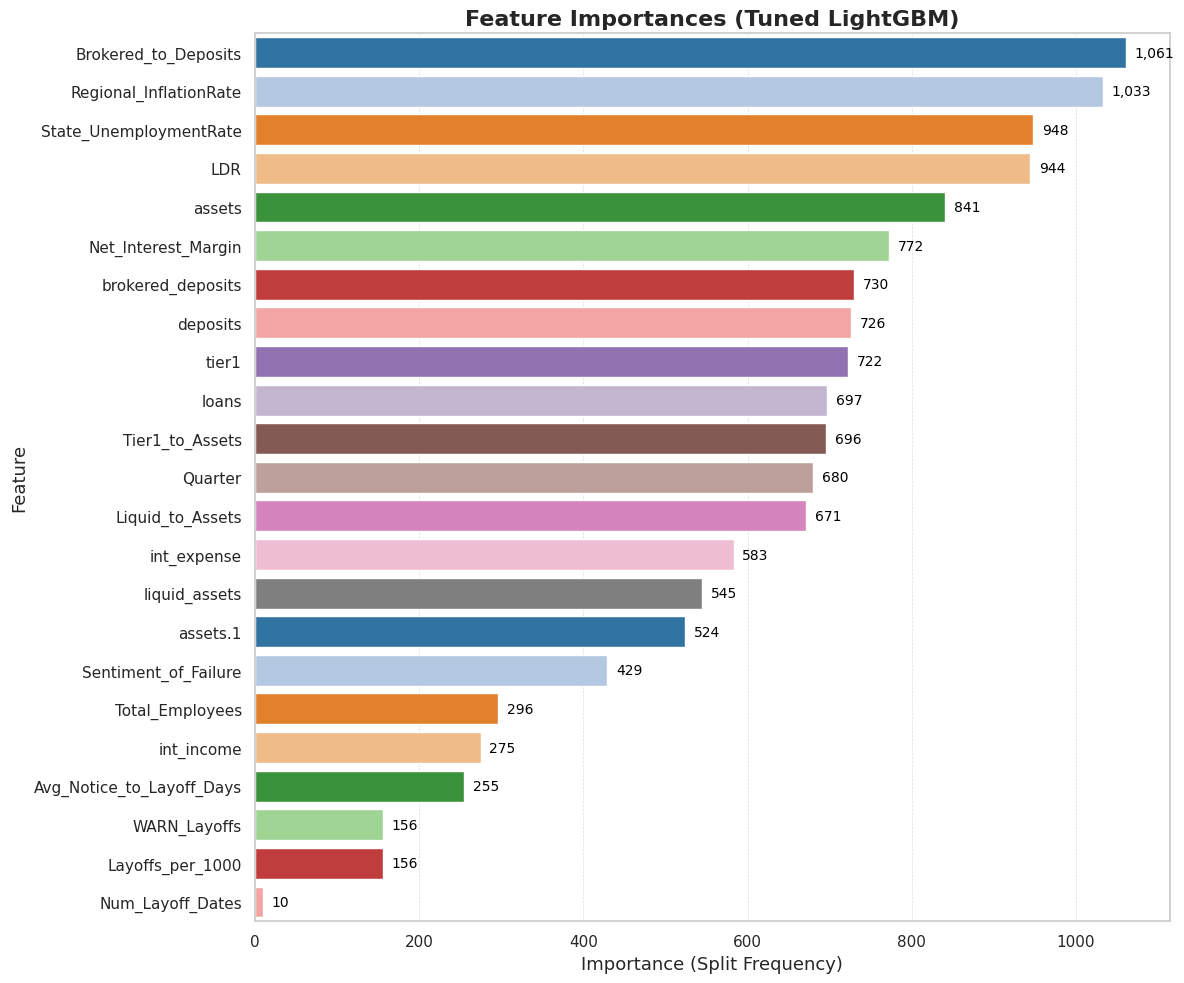

In [ ]:
# lightgbm feature importance
# Prepare feature importance data
feat_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tuned_lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Keep only the top 15 features
top_feat_imp_df = feat_imp_df.head(15).sort_values(by='Importance', ascending=True)

# color palette
colors = sns.color_palette("tab20", n_colors=15)

# Plot
plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

barplot = sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp_df,
    palette=colors
)

# Annotate value on right end of each bar
for i, (importance, feature) in enumerate(zip(feat_imp_df['Importance'], feat_imp_df['Feature'])):
    plt.text(
        importance + max(feat_imp_df['Importance']) * 0.01,  # slight offset
        i,
        f'{importance:,}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

# Formatting
plt.title('Feature Importances (Tuned LightGBM)', fontsize=16, fontweight='bold')
plt.xlabel('Importance (Split Frequency)', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Define feature groups for ablation test
accounting_features = [
    'loans', 'tier1', 'assets', 'int_income', 'int_expense', 'LDR',
    'Tier1_to_Assets', 'Net_Interest_Margin', 'liquid_assets',
    'assets.1', 'brokered_deposits', 'deposits',
    'Liquid_to_Assets', 'Brokered_to_Deposits'
]

macro_features = [
    'Regional_InflationRate', 'State_UnemploymentRate'
]

non_accounting_features = [
    'Total_Employees', 'WARN_Layoffs', 'Layoffs_per_1000',
    'Num_Layoff_Dates', 'Avg_Notice_to_Layoff_Days',
    'Sentiment_of_Failure'
]

# Preserve 'Quarter' column if needed later
quarter_col = ['Quarter']

# Define feature sets
feature_sets = {
    'Accounting Only': accounting_features,
    'Accounting & Macro': accounting_features + macro_features,
    'Full Features': accounting_features + macro_features + non_accounting_features
}
ordered_labels = ['Accounting Only', 'Accounting & Macro', 'Full Features']


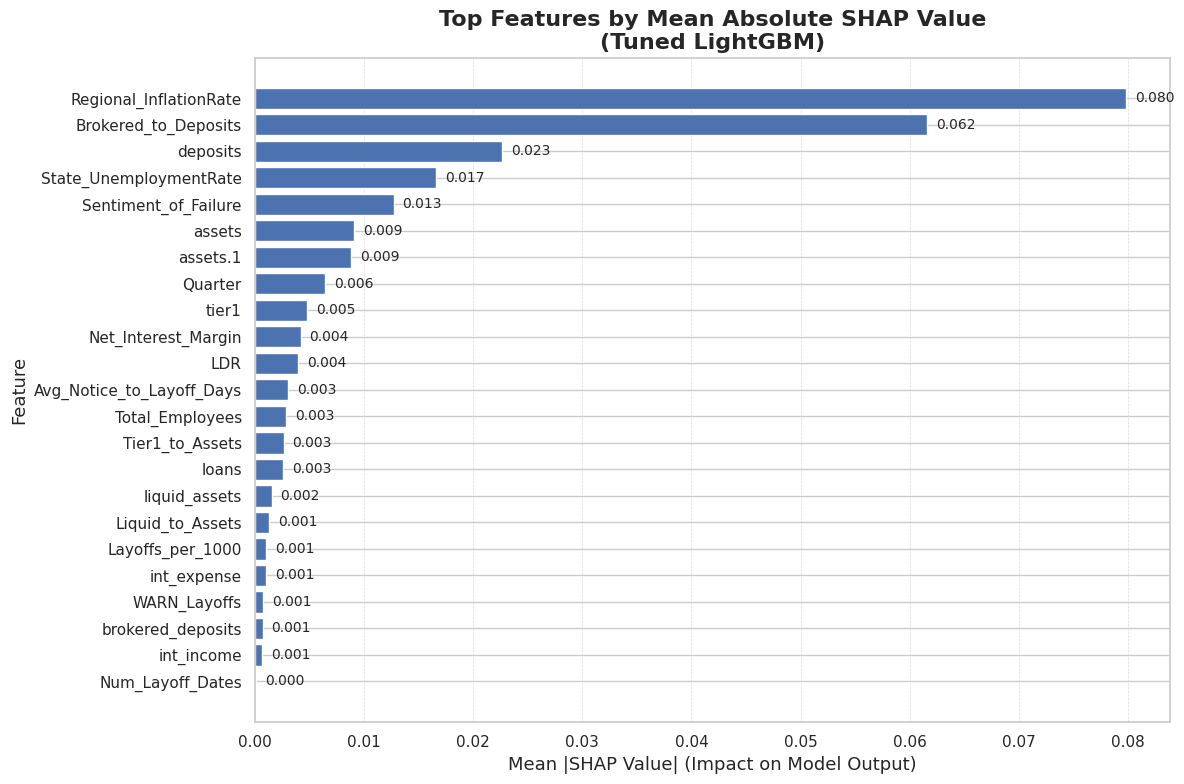

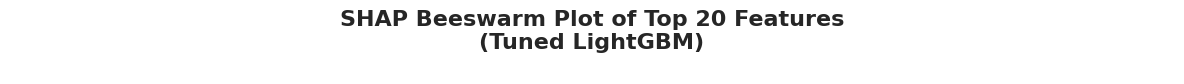

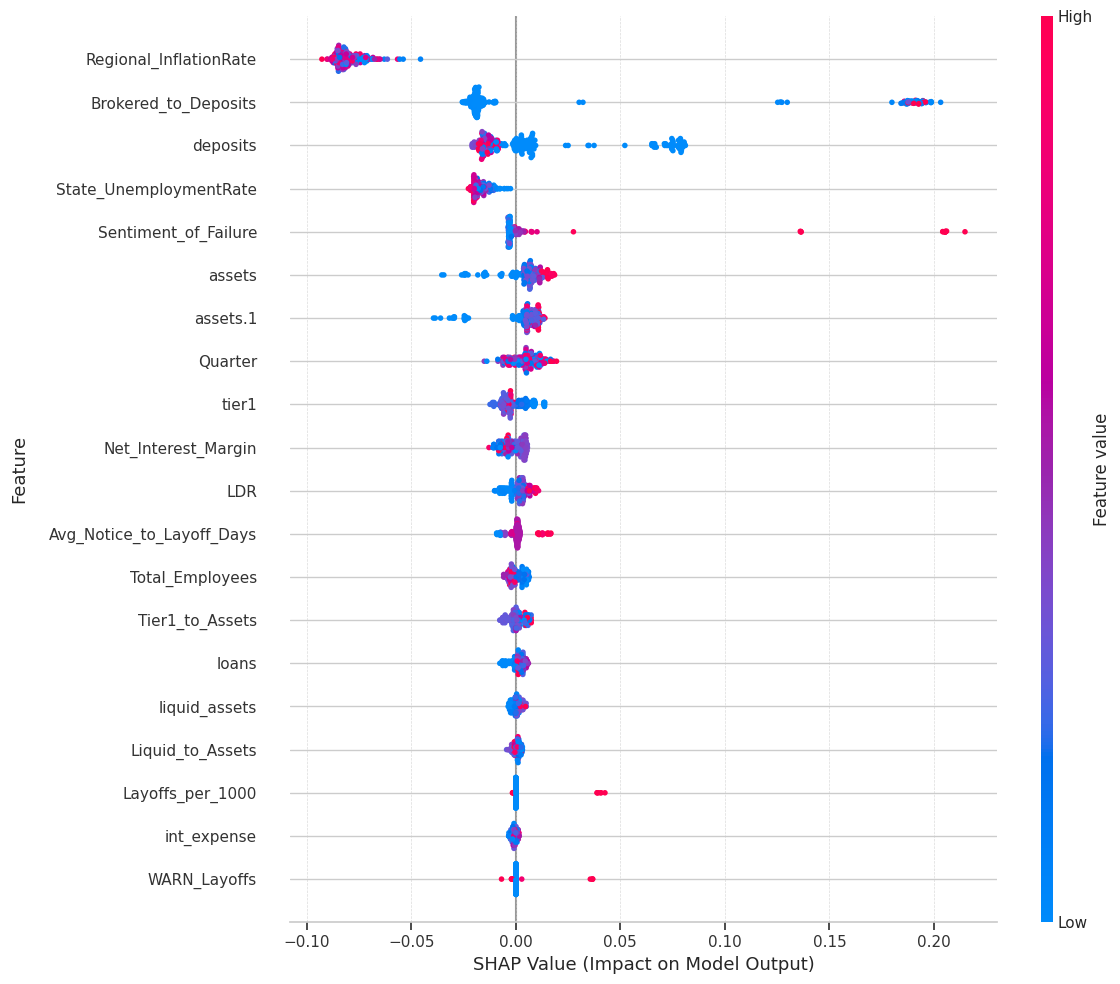

In [ ]:
# Recalculate SHAP values
explainer = shap.Explainer(tuned_lgb_model, X_train)
shap_values = explainer(X_test)

# Define custom color palettes
bar_color = sns.color_palette("deep")[0]
cmap_beeswarm = plt.get_cmap("coolwarm")

# SHAP Bar Plot
mean_abs_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'MeanAbsSHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='MeanAbsSHAP', ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    y=mean_abs_shap['Feature'],
    width=mean_abs_shap['MeanAbsSHAP'],
    color=bar_color
)

# Annotate bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(mean_abs_shap['MeanAbsSHAP']) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{width:.3f}', va='center', ha='left', fontsize=10)

# Formatting
plt.title("Top Features by Mean Absolute SHAP Value\n(Tuned LightGBM)", fontsize=16, fontweight='bold')
plt.xlabel("Mean |SHAP Value| (Impact on Model Output)", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# Spacer between plots
print("\n" * 3)

# SHAP Beeswarm Plot
# Custom plot title using matplotlib
plt.figure(figsize=(12, 1))
plt.axis("off")
plt.title("SHAP Beeswarm Plot of Top 20 Features\n(Tuned LightGBM)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Actual beeswarm plot
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    plot_size=(12, 10),
    color=cmap_beeswarm,
    show=False
)

plt.ylabel("Feature", fontsize=13, labelpad=15)
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# define feature groups for ablation test
accounting_features = [
    'loans', 'tier1', 'assets', 'int_income', 'int_expense', 'LDR',
    'Tier1_to_Assets', 'Net_Interest_Margin', 'liquid_assets',
    'assets.1', 'brokered_deposits', 'deposits',
    'Liquid_to_Assets', 'Brokered_to_Deposits'
]

macro_features = [
    'Regional_InflationRate', 'State_UnemploymentRate'
]

non_accounting_features = [
    'Total_Employees', 'WARN_Layoffs', 'Layoffs_per_1000',
    'Num_Layoff_Dates', 'Avg_Notice_to_Layoff_Days',
    'Sentiment_of_Failure'
]

# preserve quarter since it was in model training
quarter_col = ['Quarter']

In [ ]:
# Ablation feature sets and labels
feature_sets = {
    'Accounting Only': accounting_features,
    'Accounting & Macro': accounting_features + macro_features,
    'Full Features': accounting_features + macro_features + non_accounting_features
}
ordered_labels = ['Accounting Only', 'Accounting & Macro', 'Full Features']

# Dictionary to store R2 scores and predictions for statistical testing
ablation_results = {}
predictions_ablation = {}

# Fit models on each feature set and store predictions and R2 scores
for label in ordered_labels:
    selected_features = feature_sets[label]
    X_train_ab = X_train[selected_features]
    X_test_ab = X_test[selected_features]

    ab_model = clone(tuned_lgb_model)
    ab_model.fit(X_train_ab, y_train)
    y_pred_ab = ab_model.predict(X_test_ab)

    ab_r2 = r2_score(y_test, y_pred_ab)
    ablation_results[label] = ab_r2
    predictions_ablation[label] = y_pred_ab

# --- Bootstrap CI function for R2 ---
def bootstrap_r2(y_true, y_pred, n_bootstrap=1000, ci=95, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    boot_r2 = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        boot_r2.append(r2_score(y_true[idxs], y_pred[idxs]))
    boot_r2 = np.array(boot_r2)
    lower = np.percentile(boot_r2, (100 - ci) / 2)
    upper = np.percentile(boot_r2, 100 - (100 - ci) / 2)
    mean = boot_r2.mean()
    return mean, lower, upper

# Calculate CIs for each feature set's R2
ci_results = {}
for label in ordered_labels:
    mean_r2, ci_lower, ci_upper = bootstrap_r2(y_test.values, predictions_ablation[label])
    ci_results[label] = (mean_r2, ci_lower, ci_upper)

print("R² Scores with 95% Confidence Intervals:\n")
for label in ordered_labels:
    mean_r2, ci_lower, ci_upper = ci_results[label]
    print(f"{label}: Mean R² = {mean_r2:.4f}, 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

# --- Bootstrap test function for R2 difference (as you had) ---
def bootstrap_r2_diff(y_true, y_pred1, y_pred2, n_bootstrap=1000, ci=95, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    diffs = []
    y_true = np.array(y_true)
    y_pred1 = np.array(y_pred1)
    y_pred2 = np.array(y_pred2)
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        r2_1 = r2_score(y_true[idxs], y_pred1[idxs])
        r2_2 = r2_score(y_true[idxs], y_pred2[idxs])
        diffs.append(r2_1 - r2_2)
    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    lower = np.percentile(diffs, (100 - ci) / 2)
    upper = np.percentile(diffs, 100 - (100 - ci) / 2)
    p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    return mean_diff, lower, upper, p_value

# Perform pairwise bootstrap statistical tests
print("\nBootstrap statistical tests for R² improvements between ablation feature sets:\n")

test_pairs = [
    ('Accounting & Macro', 'Accounting Only'),
    ('Full Features', 'Accounting & Macro')
]

for higher, lower in test_pairs:
    mean_diff, ci_lower, ci_upper, p_value = bootstrap_r2_diff(
        y_test.values,
        predictions_ablation[higher],
        predictions_ablation[lower],
        n_bootstrap=1000
    )
    print(f"{higher} vs {lower}:")
    print(f"  Mean R² difference: {mean_diff:.4f}")
    print(f"  95% CI of difference: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  Bootstrap p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  => Statistically significant improvement at α=0.05\n")
    else:
        print("  => No statistically significant improvement detected\n")

# Plotting R2 results with error bars from bootstrapped CI
ci_lowers = [ci_results[label][1] for label in ordered_labels]
ci_uppers = [ci_results[label][2] for label in ordered_labels]
means = [ci_results[label][0] for label in ordered_labels]
errors = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
colors = sns.color_palette("tab20")[:3]

barplot = sns.barplot(
    data=ablation_df,
    x='Feature Set',
    y='R2',
    palette=colors,
    order=ordered_labels
)

# Add error bars
plt.errorbar(
    x=range(len(ordered_labels)),
    y=means,
    yerr=errors,
    fmt='none',
    c='black',
    capsize=5,
    capthick=1.5,
    lw=1.5
)

# Add text labels inside bars
for i, r2_val in enumerate(means):
    plt.text(
        x=i,
        y=r2_val / 2,
        s=f"{r2_val:.3f}",
        ha='center',
        va='center',
        fontsize=12,
        color='white' if r2_val > 0.5 else 'black',
        fontweight='bold'
    )

plt.title("Ablation Study: Predictive Contribution of Feature Groups", fontsize=16, fontweight='bold')
plt.ylabel("R² Score (Test Set)", fontsize=13)
plt.xlabel("Feature Group", fontsize=13)
plt.ylim(0, max(ci_uppers) + 0.1)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 990, number of used features: 14
[LightGBM] [Info] Start training from score 0.295203
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

NameError: name 'ablation_df' is not defined

<Figure size 1000x600 with 0 Axes>

[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 990, number of used features: 14
[LightGBM] [Info] Start training from score 0.295203
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/tmp/ipython-input-3780286942.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


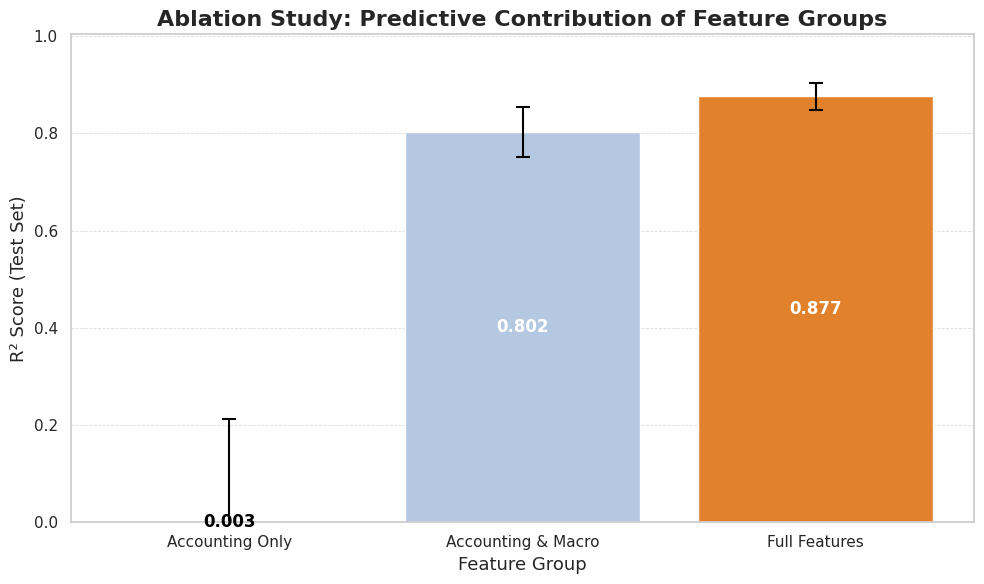

In [ ]:
# --- Define Feature Groups ---
accounting_features = [
    'loans', 'tier1', 'assets', 'int_income', 'int_expense', 'LDR',
    'Tier1_to_Assets', 'Net_Interest_Margin', 'liquid_assets',
    'assets.1', 'brokered_deposits', 'deposits',
    'Liquid_to_Assets', 'Brokered_to_Deposits'
]

macro_features = [
    'Regional_InflationRate', 'State_UnemploymentRate'
]

non_accounting_features = [
    'Total_Employees', 'WARN_Layoffs', 'Layoffs_per_1000',
    'Num_Layoff_Dates', 'Avg_Notice_to_Layoff_Days',
    'Sentiment_of_Failure'
]

# Optional: Preserve for merging time info later
quarter_col = ['Quarter']

feature_sets = {
    'Accounting Only': accounting_features,
    'Accounting & Macro': accounting_features + macro_features,
    'Full Features': accounting_features + macro_features + non_accounting_features
}
ordered_labels = ['Accounting Only', 'Accounting & Macro', 'Full Features']

# --- Fit Models and Collect R² Scores ---
ablation_results = {}
predictions_ablation = {}

for label in ordered_labels:
    selected_features = feature_sets[label]
    X_train_ab = X_train[selected_features]
    X_test_ab = X_test[selected_features]

    ab_model = clone(tuned_lgb_model)
    ab_model.fit(X_train_ab, y_train)
    y_pred_ab = ab_model.predict(X_test_ab)

    ab_r2 = r2_score(y_test, y_pred_ab)
    ablation_results[label] = ab_r2
    predictions_ablation[label] = y_pred_ab

# --- Bootstrap CI for R² ---
def bootstrap_r2(y_true, y_pred, n_bootstrap=1000, ci=95, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    boot_r2 = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        boot_r2.append(r2_score(y_true[idxs], y_pred[idxs]))
    boot_r2 = np.array(boot_r2)
    lower = np.percentile(boot_r2, (100 - ci) / 2)
    upper = np.percentile(boot_r2, 100 - (100 - ci) / 2)
    mean = boot_r2.mean()
    return mean, lower, upper

# --- Calculate CIs ---
ci_results = {}
for label in ordered_labels:
    mean_r2, ci_lower, ci_upper = bootstrap_r2(y_test.values, predictions_ablation[label])
    ci_results[label] = (mean_r2, ci_lower, ci_upper)

# --- Create DataFrame for Plotting ---
means = [ci_results[label][0] for label in ordered_labels]
ci_lowers = [ci_results[label][1] for label in ordered_labels]
ci_uppers = [ci_results[label][2] for label in ordered_labels]
errors = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

ablation_df = pd.DataFrame({
    'Feature Set': ordered_labels,
    'R2': means
})

# --- Plotting ---
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
colors = sns.color_palette("tab20")[:3]

barplot = sns.barplot(
    data=ablation_df,
    x='Feature Set',
    y='R2',
    palette=colors,
    order=ordered_labels
)

# Add error bars manually
plt.errorbar(
    x=range(len(ordered_labels)),
    y=means,
    yerr=errors,
    fmt='none',
    c='black',
    capsize=5,
    capthick=1.5,
    lw=1.5
)

# Add value labels
for i, r2_val in enumerate(means):
    plt.text(
        x=i,
        y=r2_val / 2,
        s=f"{r2_val:.3f}",
        ha='center',
        va='center',
        fontsize=12,
        color='white' if r2_val > 0.5 else 'black',
        fontweight='bold'
    )

plt.title("Ablation Study: Predictive Contribution of Feature Groups", fontsize=16, fontweight='bold')
plt.ylabel("R² Score (Test Set)", fontsize=13)
plt.xlabel("Feature Group", fontsize=13)
plt.ylim(0, max(ci_uppers) + 0.1)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Use tuned LightGBM from earlier
models = {
    'Tuned LightGBM': tuned_lgb_model,
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'XGBoost': XGBRegressor(random_state=42)
}

print("=== Model Benchmarking ===")
for name, model in models.items():
    # Only retrain if not already tuned
    if name != 'Tuned LightGBM':
        model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    brier = mse  # Adapted Brier = MSE in regression

    print(f"{name} -> MSE: {mse:.4f}, R²: {r2:.4f}, Brier: {brier:.4f}")

=== Model Benchmarking ===
Tuned LightGBM -> MSE: 0.0030, R²: 0.8900, Brier: 0.0030
Random Forest -> MSE: 0.0039, R²: 0.8593, Brier: 0.0039
Ridge Regression -> MSE: 0.0218, R²: 0.2032, Brier: 0.0218


/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=2.85054e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


XGBoost -> MSE: 0.0046, R²: 0.8325, Brier: 0.0046


/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=2.85054e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/tmp/ipython-input-3796221476.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3796221476.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


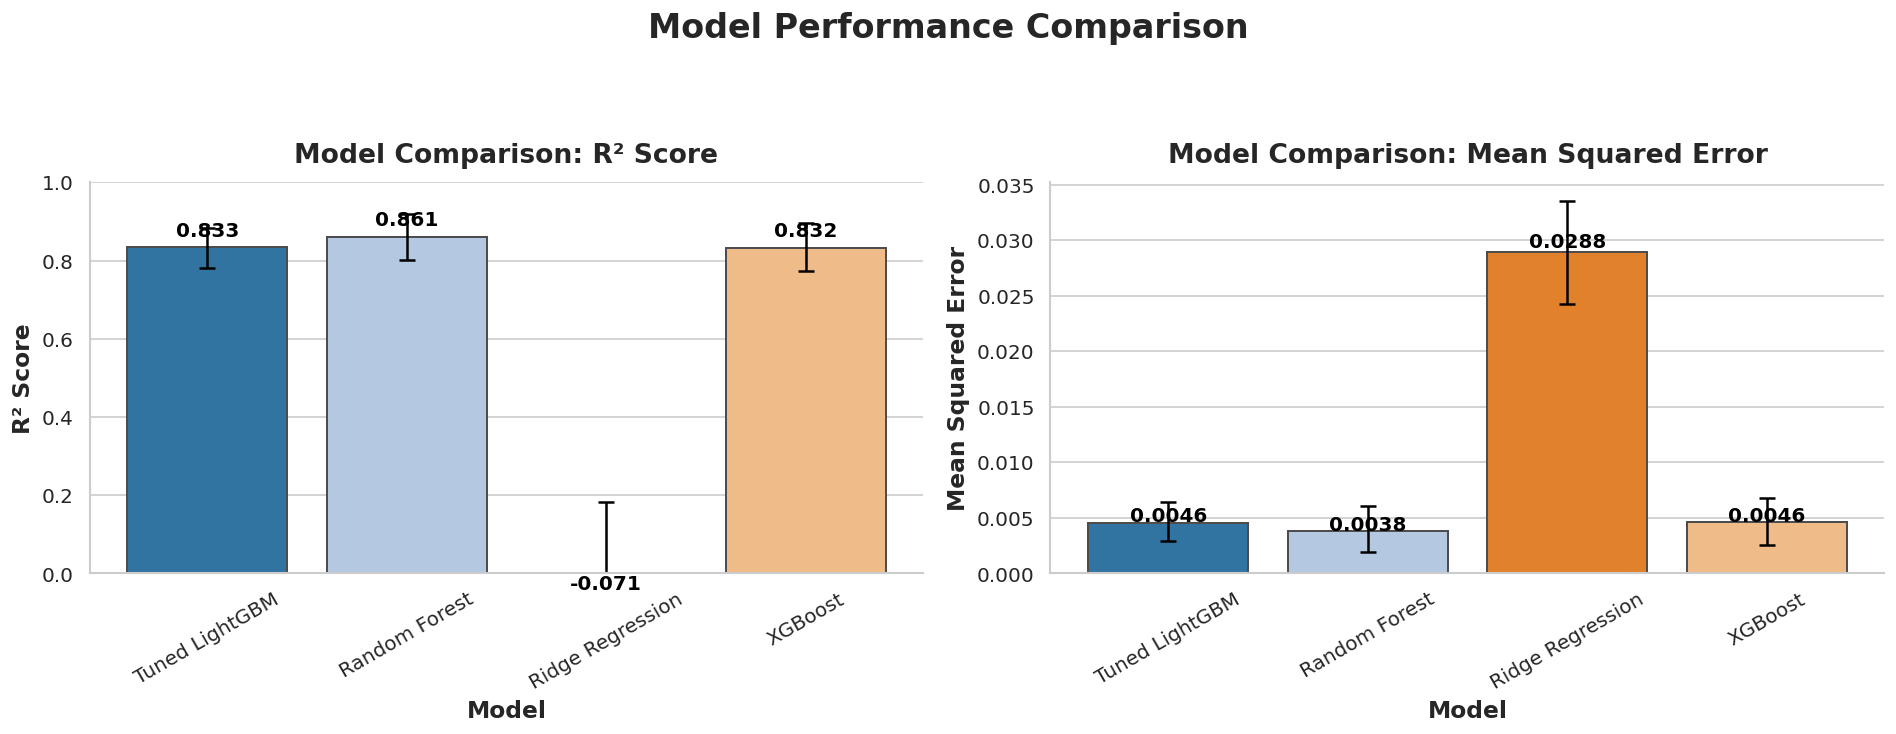


Pairwise Bootstrap Statistical Tests:

=== R2 Score ===
Tuned LightGBM vs Random Forest: mean difference = -0.0279 (decrease), 95% CI = [-0.0589, 0.0016], p-value = 0.0740
Tuned LightGBM vs Ridge Regression: mean difference = 0.9035 (increase), 95% CI = [0.6523, 1.1992], p-value = 0.0000
Tuned LightGBM vs XGBoost: mean difference = 0.0002 (increase), 95% CI = [-0.0226, 0.0230], p-value = 0.9820
Random Forest vs Ridge Regression: mean difference = 0.9313 (increase), 95% CI = [0.6635, 1.2478], p-value = 0.0000
Random Forest vs XGBoost: mean difference = 0.0281 (increase), 95% CI = [-0.0012, 0.0615], p-value = 0.0660
Ridge Regression vs XGBoost: mean difference = -0.9033 (decrease), 95% CI = [-1.2095, -0.6442], p-value = 0.0000

=== MSE ===
Tuned LightGBM vs Random Forest: mean difference = 0.0007 (increase), 95% CI = [-0.0001, 0.0014], p-value = 0.0740
Tuned LightGBM vs Ridge Regression: mean difference = -0.0242 (decrease), 95% CI = [-0.0294, -0.0194], p-value = 0.0000
Tuned LightGBM v

In [ ]:
# 1) Define and fit models, generate predictions_dict
predictions_dict = {}

models = {
    'Tuned LightGBM': tuned_lgb_model,
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'XGBoost': XGBRegressor(random_state=42)
}

for name, model in models.items():
    # Fit if not pretrained (assuming tuned_lgb is pretrained)
    if name != 'Tuned LightGBM':
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    # Normalize Ridge predictions if desired (same as before)
    if name == 'Ridge Regression':
        preds = (preds - preds.min()) / (preds.max() - preds.min())
    predictions_dict[name] = preds

# 2) Calculate metrics for each model and build results_df
results = []
for name, preds in predictions_dict.items():
    r2 = r2_score(y_test, preds)
    mse = np.mean((y_test - preds) ** 2)
    results.append({'Model': name, 'R2 Score': r2, 'MSE': mse})
results_df = pd.DataFrame(results)

# 3) Bootstrap CI and test functions
def bootstrap_metric_ci(y_true, y_pred, metric_func, n_bootstrap=1000, ci=95, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    scores = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        score = metric_func(y_true[idxs], y_pred[idxs])
        scores.append(score)
    scores = np.array(scores)
    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    mean = scores.mean()
    return mean, lower, upper, scores

def bootstrap_metric_diff_test(y_true, y_pred1, y_pred2, metric_func, n_bootstrap=1000, ci=95, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    diffs = []
    y_true = np.array(y_true)
    y_pred1 = np.array(y_pred1)
    y_pred2 = np.array(y_pred2)
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        score1 = metric_func(y_true[idxs], y_pred1[idxs])
        score2 = metric_func(y_true[idxs], y_pred2[idxs])
        diffs.append(score1 - score2)
    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    lower = np.percentile(diffs, (100 - ci) / 2)
    upper = np.percentile(diffs, 100 - (100 - ci) / 2)
    p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    return mean_diff, lower, upper, p_value

# 4) Compute CIs and bootstrap samples for plotting and testing
metric_info = {
    'R2 Score': {
        'func': lambda y_true, y_pred: r2_score(y_true, y_pred),
        'means': [],
        'lowers': [],
        'uppers': [],
        'boot_samples': {}
    },
    'MSE': {
        'func': lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2),
        'means': [],
        'lowers': [],
        'uppers': [],
        'boot_samples': {}
    }
}

for metric in ['R2 Score', 'MSE']:
    for _, row in results_df.iterrows():
        model_name = row['Model']
        y_pred = predictions_dict[model_name]
        mean, lower, upper, boot_samples = bootstrap_metric_ci(
            y_test,
            y_pred,
            metric_info[metric]['func'],
            n_bootstrap=1000
        )
        metric_info[metric]['means'].append(mean)
        metric_info[metric]['lowers'].append(lower)
        metric_info[metric]['uppers'].append(upper)
        metric_info[metric]['boot_samples'][model_name] = boot_samples

# 5) Plot with error bars
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)
tab20_colors = sns.color_palette("tab20")[:len(results_df)]

# R² Score plot
sns.barplot(
    ax=axes[0],
    data=results_df,
    x='Model',
    y='R2 Score',
    palette=tab20_colors,
    edgecolor=".3",
    linewidth=1.2
)
axes[0].errorbar(
    x=np.arange(len(results_df)),
    y=metric_info['R2 Score']['means'],
    yerr=[np.array(metric_info['R2 Score']['means']) - np.array(metric_info['R2 Score']['lowers']),
          np.array(metric_info['R2 Score']['uppers']) - np.array(metric_info['R2 Score']['means'])],
    fmt='none',
    c='black',
    capsize=5,
    capthick=1.5,
    lw=1.5
)
axes[0].set_title("Model Comparison: R² Score", fontsize=16, fontweight='bold', pad=12)
axes[0].set_xlabel("Model", fontsize=14, fontweight='semibold')
axes[0].set_ylabel("R² Score", fontsize=14, fontweight='semibold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)

for i, mean_r2 in enumerate(metric_info['R2 Score']['means']):
    axes[0].text(
        i,
        mean_r2 + 0.03,
        f"{mean_r2:.3f}",
        ha='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

# MSE plot
sns.barplot(
    ax=axes[1],
    data=results_df,
    x='Model',
    y='MSE',
    palette=tab20_colors,
    edgecolor=".3",
    linewidth=1.2
)
axes[1].errorbar(
    x=np.arange(len(results_df)),
    y=metric_info['MSE']['means'],
    yerr=[np.array(metric_info['MSE']['means']) - np.array(metric_info['MSE']['lowers']),
          np.array(metric_info['MSE']['uppers']) - np.array(metric_info['MSE']['means'])],
    fmt='none',
    c='black',
    capsize=5,
    capthick=1.5,
    lw=1.5
)
axes[1].set_title("Model Comparison: Mean Squared Error", fontsize=16, fontweight='bold', pad=12)
axes[1].set_xlabel("Model", fontsize=14, fontweight='semibold')
axes[1].set_ylabel("Mean Squared Error", fontsize=14, fontweight='semibold')
axes[1].tick_params(axis='x', rotation=30, labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

for i, mean_mse in enumerate(metric_info['MSE']['means']):
    axes[1].text(
        i,
        mean_mse * 1.02,
        f"{mean_mse:.4f}",
        ha='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

plt.suptitle("Model Performance Comparison", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
for ax in axes:
    sns.despine(ax=ax, top=True, right=True)
plt.show()

# 6) Pairwise bootstrap tests for significance
from itertools import combinations

print("\nPairwise Bootstrap Statistical Tests:")

for metric in ['R2 Score', 'MSE']:
    print(f"\n=== {metric} ===")
    boot_samples = metric_info[metric]['boot_samples']
    for m1, m2 in combinations(results_df['Model'], 2):
        diffs = boot_samples[m1] - boot_samples[m2]
        mean_diff = diffs.mean()
        lower = np.percentile(diffs, 2.5)
        upper = np.percentile(diffs, 97.5)
        p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
        direction = "increase" if mean_diff > 0 else "decrease"
        print(f"{m1} vs {m2}: mean difference = {mean_diff:.4f} ({direction}), 95% CI = [{lower:.4f}, {upper:.4f}], p-value = {p_value:.4f}")

Tuned LightGBM: AUROC = 0.990 (95% CI: 0.971–1.000)
Random Forest: AUROC = 0.999 (95% CI: 0.997–1.000)


/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=2.85054e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Ridge Regression: AUROC = 0.814 (95% CI: 0.758–0.867)
XGBoost: AUROC = 0.998 (95% CI: 0.994–1.000)


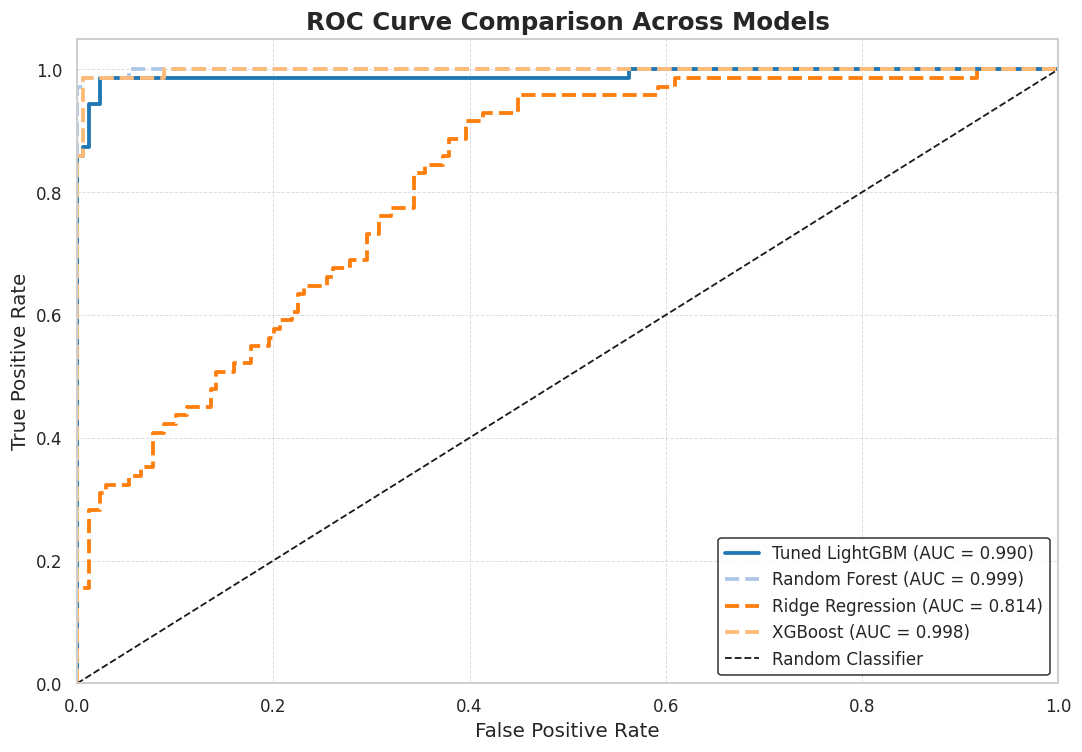


Bootstrapped Pairwise AUROC Comparison:
         Model 1          Model 2  Mean ΔAUC  p-value
  Tuned LightGBM Ridge Regression     0.1741   0.0000
   Random Forest Ridge Regression     0.1832   0.0000
Ridge Regression          XGBoost    -0.1821   0.0000
  Tuned LightGBM    Random Forest    -0.0091   0.1480
  Tuned LightGBM          XGBoost    -0.0080   0.3380
   Random Forest          XGBoost     0.0011   0.5180


In [ ]:
# --- Binarize Target ---
threshold = 0.5
y_test_binary = (y_test >= threshold).astype(int)

# --- Define Models ---
models = {
    'Tuned LightGBM': tuned_lgb_model,
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'XGBoost': XGBRegressor(random_state=42)
}

# --- Compute ROC/AUC ---
roc_results = {}
boot_auc_scores = {}
n_bootstraps = 1000
rng = np.random.RandomState(42)

for name, model in models.items():
    if name != 'Tuned LightGBM':  # Only LightGBM is pre-fitted
        model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # Normalize Ridge output
    if name == "Ridge Regression":
        preds = (preds - preds.min()) / (preds.max() - preds.min())

    fpr, tpr, _ = roc_curve(y_test_binary, preds)
    auc = roc_auc_score(y_test_binary, preds)
    roc_results[name] = (fpr, tpr, auc, preds)  # store preds for bootstrapping

    # --- Bootstrap for Confidence Interval ---
    y_array = np.array(y_test_binary)
    pred_array = np.array(preds)
    boot_scores = []

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_array), len(y_array))
        if len(np.unique(y_array[indices])) < 2:
            continue
        score = roc_auc_score(y_array[indices], pred_array[indices])
        boot_scores.append(score)

    boot_scores = np.array(boot_scores)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    print(f"{name}: AUROC = {auc:.3f} (95% CI: {ci_lower:.3f}–{ci_upper:.3f})")
    boot_auc_scores[name] = boot_scores

# --- Plot ROC Curves ---
sns.set(style="whitegrid")
plt.figure(figsize=(10, 7), dpi=110)
colors = sns.color_palette("tab20", n_colors=len(roc_results))

for i, (name, (fpr, tpr, auc, _)) in enumerate(roc_results.items()):
    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC = {auc:.3f})",
        linewidth=2.5,
        linestyle='-' if 'Tuned' in name else '--',
        color=colors[i]
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label="Random Classifier")
plt.title("ROC Curve Comparison Across Models", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
plt.legend(loc='lower right', fontsize=11, frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()

# --- Pairwise AUROC Comparison via Bootstrapping ---
pairwise_results = []
model_names = list(boot_auc_scores.keys())

for m1, m2 in combinations(model_names, 2):
    aucs1 = np.array(boot_auc_scores[m1])
    aucs2 = np.array(boot_auc_scores[m2])

    min_len = min(len(aucs1), len(aucs2))
    diffs = aucs1[:min_len] - aucs2[:min_len]

    p_val = 2 * min(np.mean(diffs > 0), np.mean(diffs < 0))
    pairwise_results.append({
        "Model 1": m1,
        "Model 2": m2,
        "Mean ΔAUC": np.mean(diffs),
        "p-value": p_val
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values("p-value")
print("\nBootstrapped Pairwise AUROC Comparison:")
print(pairwise_df.to_string(index=False, float_format="%.4f"))

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=2.85054e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/tmp/ipython-input-1434472527.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1434472527.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1434472527.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1434472527.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is 

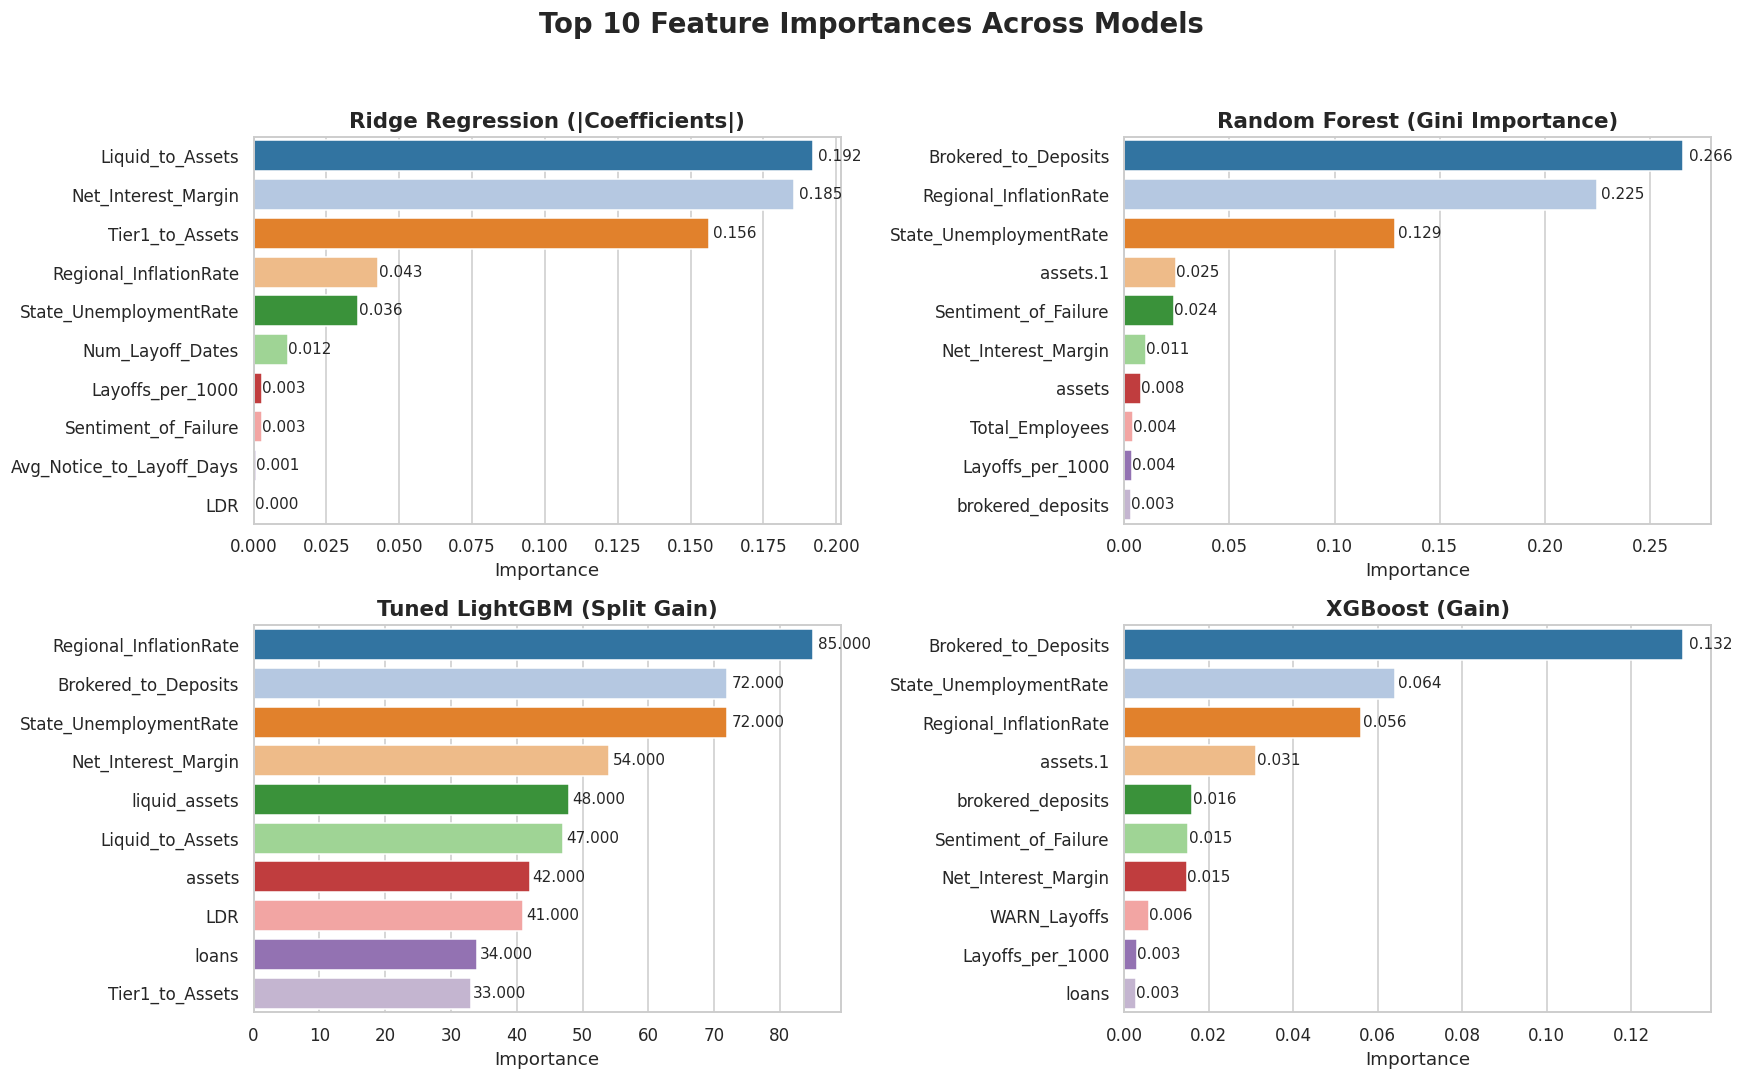

In [ ]:
# Fit untuned baseline models
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
xgb_model = XGBRegressor(random_state=42)

rf_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Exclude Quarter Feature
exclude_features = ["Quarter"]

# Extract top N features
def get_top_features(importances, feature_names, top_n=10):
    df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df = df[~df['Feature'].isin(exclude_features)]
    df = df.sort_values(by='Importance', ascending=False).head(top_n)
    return df

# Ridge Regression
ridge_importances = np.abs(ridge_model.coef_)
ridge_df = get_top_features(ridge_importances, X_train.columns)

# Random Forest
rf_df = get_top_features(rf_model.feature_importances_, X_train.columns)

# Tuned LightGBM
lgb_df = get_top_features(tuned_lgb_model.feature_importances_, tuned_lgb_model.feature_name_)

# XGBoost
xgb_df = get_top_features(xgb_model.feature_importances_, xgb_model.feature_names_in_)

# Plot Setup
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=110)
fig.suptitle("Top 10 Feature Importances Across Models", fontsize=18, fontweight='bold')

color_palette = sns.color_palette("tab20", n_colors=10)

# Plotting Function
def plot_importance_bar(ax, df, title):
    sns.barplot(
        ax=ax,
        x="Importance",
        y="Feature",
        data=df,
        palette=color_palette
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Importance", fontsize=12)
    ax.set_ylabel("")
    ax.tick_params(labelsize=11)

    for i, (val, _) in enumerate(zip(df["Importance"], df["Feature"])):
        ax.text(val * 1.01, i, f"{val:.3f}", va='center', fontsize=10)

# Create Each Plot
plot_importance_bar(axes[0, 0], ridge_df, "Ridge Regression (|Coefficients|)")
plot_importance_bar(axes[0, 1], rf_df, "Random Forest (Gini Importance)")
plot_importance_bar(axes[1, 0], lgb_df, "Tuned LightGBM (Split Gain)")
plot_importance_bar(axes[1, 1], xgb_df, "XGBoost (Gain)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
def spearman_bootstrap_ci(y_true, y_pred, n_bootstrap=1000, ci=95, random_state=42):
    """Bootstrap confidence interval for Spearman correlation."""
    np.random.seed(random_state)
    n = len(y_true)
    boot_corrs = []
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        corr, _ = spearmanr(y_true[idxs], y_pred[idxs])
        boot_corrs.append(corr)
    boot_corrs = np.array(boot_corrs)
    lower = np.percentile(boot_corrs, (100 - ci) / 2)
    upper = np.percentile(boot_corrs, 100 - (100 - ci) / 2)
    mean_corr = np.mean(boot_corrs)
    return mean_corr, lower, upper, boot_corrs

# Assuming predictions dict and y_test defined as in original code
# predictions = {
#     "Tuned LightGBM": tuned_lgb.predict(X_test),
#     "XGBoost": xgb_model.predict(X_test),
#     "Random Forest": rf_model.predict(X_test),
#     "Ridge Regression": ridge_model.predict(X_test)
# }
# y_test = ...

# Calculate bootstrap CI and bootstrap samples for Spearman ρ
spearman_results = {}
for model_name, preds in predictions.items():
    mean_corr, ci_lower, ci_upper, boots = spearman_bootstrap_ci(y_test.values, preds)
    spearman_results[model_name] = {
        "mean_corr": mean_corr,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "boots": boots
    }

# Format DataFrame for heatmap plotting
spearman_df = pd.DataFrame({
    model: [vals["mean_corr"], vals["ci_lower"], vals["ci_upper"]]
    for model, vals in spearman_results.items()
}, index=["Mean", "CI Lower", "CI Upper"]).T.sort_values(by="Mean", ascending=False)

# Plot heatmap of mean Spearman correlations
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4), dpi=110)
tab20_cmap = plt.get_cmap("tab20")

ax = sns.heatmap(
    spearman_df[["Mean"]],
    annot=True,
    cmap=tab20_cmap,
    fmt=".3f",
    linewidths=0.7,
    cbar_kws={
        'label': 'Spearman Rank Correlation (ρ)',
        'shrink': 0.8,
        'orientation': 'vertical'
    },
    annot_kws={"size": 11, "weight": "bold"}
)

ax.set_ylabel("Model", fontsize=12, labelpad=10)
plt.title("Spearman Rank Correlation with 95% CI: Predictions vs. True Risk Scores", fontsize=14, fontweight='bold', pad=14)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
ax.figure.axes[-1].yaxis.label.set_size(12)
plt.tight_layout()
plt.show()

# Wilcoxon signed-rank test: Tuned LightGBM vs Random Forest Spearman boots
boots_lgb = spearman_results["Tuned LightGBM"]["boots"]
boots_rf = spearman_results["Random Forest"]["boots"]

stat, p_value = wilcoxon(boots_lgb, boots_rf)
print(f"Wilcoxon signed-rank test comparing Spearman ρ of Tuned LightGBM vs Random Forest:")
print(f"Statistic={stat}, p-value={p_value:.4f}")
if p_value < 0.05:
    print("=> Statistically significant difference in Spearman correlation at α=0.05")
else:
    print("=> No statistically significant difference detected")

NameError: name 'predictions' is not defined

In [ ]:
# ---- Precision@K Functions ----
def precision_at_k(y_true, y_pred, k):
    pred_top_k = np.argsort(y_pred)[-k:][::-1]
    true_top_k = np.argsort(y_true)[-k:][::-1]
    return len(set(pred_top_k) & set(true_top_k)) / k

def bootstrap_precision_at_k(y_true, y_pred, k, n_bootstrap=1000, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    bootstrapped_scores = []
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        score = precision_at_k(y_true[idxs], y_pred[idxs], k)
        bootstrapped_scores.append(score)
    return np.array(bootstrapped_scores)

# ---- Model Predictions and Ground Truth (Assumed to be defined) ----
# predictions = {
#     "Tuned LightGBM": tuned_lgb.predict(X_test),
#     "XGBoost": xgb_model.predict(X_test),
#     "Random Forest": rf_model.predict(X_test),
#     "Ridge Regression": ridge_model.predict(X_test)
# }
# y_test = ...

k_values = [5, 10, 20]
n_bootstrap = 10000

# ---- Bootstrap Precision@K scores ----
bootstrap_results = {model: {k: None for k in k_values} for model in predictions.keys()}

for model_name, preds in predictions.items():
    for k in k_values:
        samples = bootstrap_precision_at_k(y_test.values, preds, k, n_bootstrap=n_bootstrap)
        bootstrap_results[model_name][k] = samples

# ---- Prepare data for plotting ----
precision_records = []
for k in k_values:
    for model_name in predictions.keys():
        samples = bootstrap_results[model_name][k]
        mean_score = samples.mean()
        lower_ci = np.percentile(samples, 2.5)
        upper_ci = np.percentile(samples, 97.5)
        precision_records.append({
            "Model": model_name,
            "K": f"@{k}",
            "Precision@K": mean_score,
            "CI Lower": lower_ci,
            "CI Upper": upper_ci
        })

precision_df = pd.DataFrame(precision_records)

# ---- Plotting ----
sns.set(style="whitegrid")
tab20_colors = sns.color_palette("tab20", len(predictions))

plt.figure(figsize=(10, 6), dpi=120)
ax = sns.barplot(
    data=precision_df,
    x="Model",
    y="Precision@K",
    hue="K",
    palette=tab20_colors[:len(k_values)],
    capsize=0.1
)

# Add CI error bars
for i, row in precision_df.iterrows():
    x_loc = i // len(k_values) + (i % len(k_values)) * 0.2 - 0.2  # approximate x-position offset
    ax.errorbar(
        x=x_loc,
        y=row["Precision@K"],
        yerr=[[row["Precision@K"] - row["CI Lower"]], [row["CI Upper"] - row["Precision@K"]]],
        fmt='none',
        c='black',
        capsize=4,
        lw=1.5
    )

# Add bar labels (numeric values on top)
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 4), textcoords='offset points')

plt.title("Precision@K: Top-K Risk Ranking Accuracy with 95% CI", fontsize=15, fontweight='bold', pad=14)
plt.xlabel("Model", fontsize=13)
plt.ylabel("Precision@K", fontsize=13)
plt.ylim(0, 1.05)
plt.xticks(rotation=10, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Top-K", title_fontsize=12, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# ---- Wilcoxon signed-rank test results ----
print("\nWilcoxon signed-rank tests comparing Tuned LightGBM vs other models:")
for k in k_values:
    print(f"\nTop-{k} Precision:")
    samples_lgb = bootstrap_results["Tuned LightGBM"][k]
    for model_name in predictions.keys():
        if model_name == "Tuned LightGBM":
            continue
        samples_other = bootstrap_results[model_name][k]
        stat, p_value = wilcoxon(samples_lgb, samples_other)
        print(f"{model_name} vs Tuned LightGBM: p-value = {p_value:.4f} ", end="")
        if p_value < 0.05:
            print("(Significant difference)")
        else:
            print("(No significant difference)")

NameError: name 'predictions' is not defined

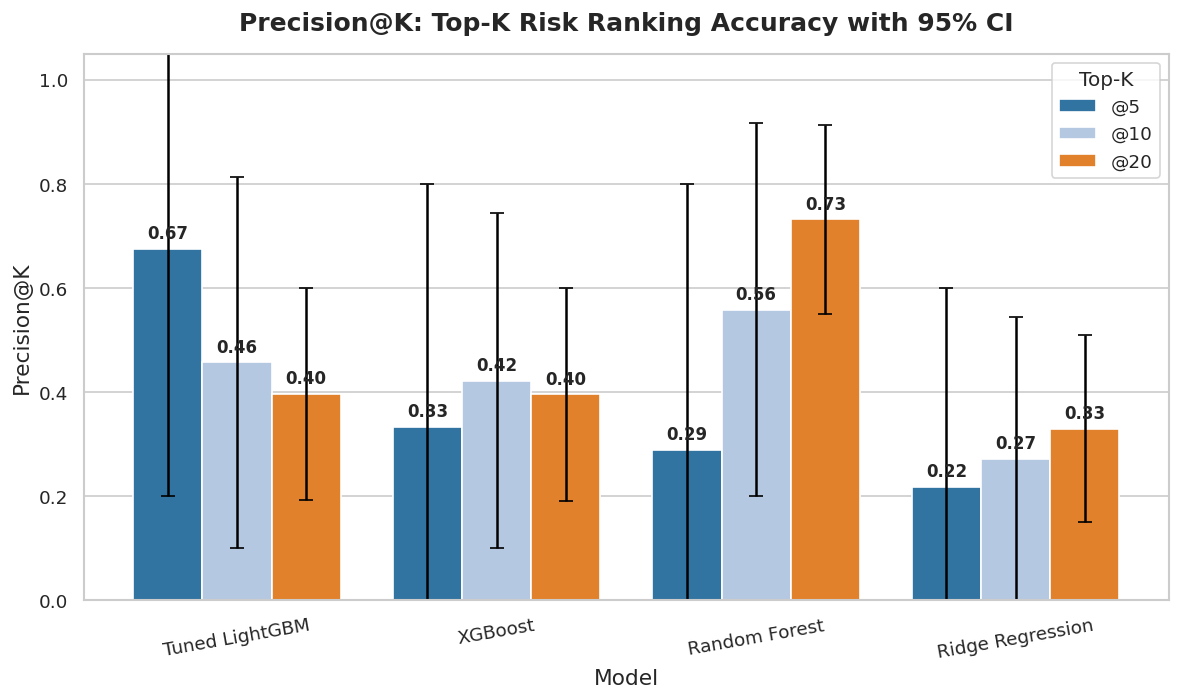


Wilcoxon signed-rank tests comparing Tuned LightGBM vs other models:

Top-5 Precision:
XGBoost vs Tuned LightGBM: p-value = 0.0000 (Significant difference)
Random Forest vs Tuned LightGBM: p-value = 0.0000 (Significant difference)
Ridge Regression vs Tuned LightGBM: p-value = 0.0000 (Significant difference)

Top-10 Precision:
XGBoost vs Tuned LightGBM: p-value = 0.0000 (Significant difference)
Random Forest vs Tuned LightGBM: p-value = 0.0000 (Significant difference)
Ridge Regression vs Tuned LightGBM: p-value = 0.0000 (Significant difference)

Top-20 Precision:
XGBoost vs Tuned LightGBM: p-value = 0.4546 (No significant difference)
Random Forest vs Tuned LightGBM: p-value = 0.0000 (Significant difference)
Ridge Regression vs Tuned LightGBM: p-value = 0.0000 (Significant difference)


In [ ]:
# ---- Precision@K Functions ----
def precision_at_k(y_true, y_pred, k):
    pred_top_k = np.argsort(y_pred)[-k:][::-1]
    true_top_k = np.argsort(y_true)[-k:][::-1]
    return len(set(pred_top_k) & set(true_top_k)) / k

def bootstrap_precision_at_k(y_true, y_pred, k, n_bootstrap=1000, random_state=42):
    np.random.seed(random_state)
    n = len(y_true)
    bootstrapped_scores = []
    for _ in range(n_bootstrap):
        idxs = np.random.choice(n, n, replace=True)
        score = precision_at_k(y_true[idxs], y_pred[idxs], k)
        bootstrapped_scores.append(score)
    return np.array(bootstrapped_scores)

# ---- Define Predictions ----
predictions = {
    "Tuned LightGBM": tuned_lgb_model.predict(X_test),
    "XGBoost": xgb_model.predict(X_test),
    "Random Forest": rf_model.predict(X_test),
    "Ridge Regression": ridge_model.predict(X_test)
}

k_values = [5, 10, 20]
n_bootstrap = 10000

# ---- Bootstrap Precision@K scores ----
bootstrap_results = {model: {k: None for k in k_values} for model in predictions.keys()}

for model_name, preds in predictions.items():
    for k in k_values:
        samples = bootstrap_precision_at_k(y_test.values, preds, k, n_bootstrap=n_bootstrap)
        bootstrap_results[model_name][k] = samples

# ---- Prepare data for plotting ----
precision_records = []
for k in k_values:
    for model_name in predictions.keys():
        samples = bootstrap_results[model_name][k]
        if np.all(np.isnan(samples)) or len(samples) == 0:
            continue  # skip corrupted
        mean_score = samples.mean()
        lower_ci = np.percentile(samples, 2.5)
        upper_ci = np.percentile(samples, 97.5)

        # Symmetric clipped error bars
        error = max(mean_score - lower_ci, upper_ci - mean_score)
        adjusted_lower = max(0, mean_score - error)
        adjusted_upper = mean_score + error

        precision_records.append({
            "Model": model_name,
            "K": f"@{k}",
            "Precision@K": mean_score,
            "CI Lower": adjusted_lower,
            "CI Upper": adjusted_upper,
            "Error": error
        })

precision_df = pd.DataFrame(precision_records)

# ---- Plotting ----
sns.set(style="whitegrid")
tab20_colors = sns.color_palette("tab20", len(predictions))

plt.figure(figsize=(10, 6), dpi=120)
ax = sns.barplot(
    data=precision_df,
    x="Model",
    y="Precision@K",
    hue="K",
    palette=tab20_colors[:len(k_values)],
    capsize=0.1
)

# Align error bars using ax.patches
for patch, (_, row) in zip(ax.patches, precision_df.iterrows()):
    center_x = patch.get_x() + patch.get_width() / 2
    y = row["Precision@K"]
    err = row["Error"]

    if y <= 0 or err <= 0:
        continue  # skip zero-height bars or zero error bars

    lower_err = min(err, y)
    upper_err = err

    ax.errorbar(
        x=center_x,
        y=y,
        yerr=[[lower_err], [upper_err]],
        fmt='none',
        c='black',
        capsize=4,
        lw=1.5
    )

# Add bar labels
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 4), textcoords='offset points')

plt.title("Precision@K: Top-K Risk Ranking Accuracy with 95% CI", fontsize=15, fontweight='bold', pad=14)
plt.xlabel("Model", fontsize=13)
plt.ylabel("Precision@K", fontsize=13)
plt.ylim(0, 1.05)
plt.xticks(rotation=10, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Top-K", title_fontsize=12, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# ---- Wilcoxon signed-rank test results ----
print("\nWilcoxon signed-rank tests comparing Tuned LightGBM vs other models:")
for k in k_values:
    print(f"\nTop-{k} Precision:")
    samples_lgb = bootstrap_results["Tuned LightGBM"][k]
    for model_name in predictions.keys():
        if model_name == "Tuned LightGBM":
            continue
        samples_other = bootstrap_results[model_name][k]
        stat, p_value = wilcoxon(samples_lgb, samples_other)
        print(f"{model_name} vs Tuned LightGBM: p-value = {p_value:.4f} ", end="")
        if p_value < 0.05:
            print("(Significant difference)")
        else:
            print("(No significant difference)")